# TMDb Movie Analytics

This notebook explores patterns in movie performance using data from The Movie Database (TMDb).  
It was created as part of a team project and focuses on understanding trends in genres, popularity, and audience engagement.

In [1]:
#Importing Pandas so to process the data
import pandas as pd

#Reading Github Raw url of our file, and giving it the name
credits = pd.read_csv('https://media.githubusercontent.com/media/Lances1127/Project-of-CIS9650/955e8bdd45532f48d7afd8be81cf0faad91c3ada/tmdb_5000_credits.csv')
movie = pd.read_csv('https://media.githubusercontent.com/media/Lances1127/Project-of-CIS9650/955e8bdd45532f48d7afd8be81cf0faad91c3ada/tmdb_5000_movies.csv')
movies= movie.merge(credits,on='title')


In [2]:
#The dimenision of our data
movies.shape

(4809, 23)

In [3]:
#Removing Duplication
movies.drop_duplicates(subset="movie_id", inplace=True)

In [4]:
#Checking duplication that is droped
movies.shape


(4803, 23)

In [5]:
#Sample of the Data, what is the format, what is the content
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [6]:
movies.shape

(4803, 23)

In [7]:
#Check for empty Cell in the dataframe
movies.isnull().sum()


,0
budget,0
genres,0
homepage,3092
id,0
keywords,0
original_language,0
original_title,0
overview,3
popularity,0
production_companies,0


In [8]:
# Filling the null space to prevent errors (Updated for Pandas 3.0+)
movies['homepage'] = movies['homepage'].fillna('')
movies['tagline'] = movies['tagline'].fillna('')
movies['overview'] = movies['overview'].fillna('')
movies['runtime'] = movies['runtime'].fillna(0)
movies['revenue'] = movies['revenue'].fillna(0)
movies['budget'] = movies['budget'].fillna(0)
movies['release_date'] = movies['release_date'].fillna('Unknown')
movies['original_language'] = movies['original_language'].fillna('Unknown')

In [9]:
#Check is Null space filed
movies.isnull().sum()

,0
budget,0
genres,0
homepage,0
id,0
keywords,0
original_language,0
original_title,0
overview,0
popularity,0
production_companies,0


In [10]:
#Checking the average of all the movies budget
budget_mean = movies['budget'].mean()
print(budget_mean)

29058910.830938995


In [11]:
#The Collection of quantitative data of the data set
movies.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count,movie_id
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4803.000000,4803.000000,4803.000000,4803.000000
mean,2.905891e+07,57185.781387,21.502615,8.234104e+07,106.835103,6.092338,690.878409,57165.484281
std,4.072026e+07,88689.395496,31.819259,1.629222e+08,22.715346,1.194664,1234.837553,88694.614033
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,5.000000
25%,7.900000e+05,9018.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000,9014.500000
50%,1.500000e+07,14635.000000,12.928269,1.917997e+07,103.000000,6.200000,236.000000,14629.000000
75%,4.000000e+07,58653.000000,28.352222,9.295652e+07,118.000000,6.800000,738.000000,58610.500000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000,459488.000000


In [12]:
#Checking the Data set information
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4803 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              4803 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4803 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4803 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4803 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status                4803

In [13]:
movies.drop_duplicates()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4804,220000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",,9367,"[{""id"": 5616, ""name"": ""united states\u2013mexi...",es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,"[{""name"": ""Columbia Pictures"", ""id"": 5}]",...,81.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238,9367,"[{""cast_id"": 1, ""character"": ""El Mariachi"", ""c...","[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de..."
4805,9000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",,72766,[],en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,[],...,85.0,[],Released,A newlywed couple's honeymoon is upended by th...,Newlyweds,5.9,5,72766,"[{""cast_id"": 1, ""character"": ""Buzzy"", ""credit_...","[{""credit_id"": ""52f

In [14]:
movies.shape

(4803, 23)

In [15]:
#Creating a function to convert the Strings to Python data type
import ast
def transform(obj):
    l = []
    for i in ast.literal_eval(obj):
        l.append(i['name'])
    return l

In [16]:
movies = movie.merge(credits, on='title')
movies['genres']=movies['genres'].apply(transform)
movies['keywords']=movies['keywords'].apply(transform)
movies['cast']=movies['cast'].apply(transform)
movies['crew']=movies['crew'].apply(transform)
movies['spoken_languages']=movies['spoken_languages'].apply(transform)
movies['production_companies']=movies['production_companies'].apply(transform)
movies['production_countries']=movies['production_countries'].apply(transform)

In [17]:
# To see all columns of the data set and see what need to be cleaned
pd.set_option('display.max_columns', None)
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",http://www.avatarmovie.com/,19995,"[culture clash, future, space war, space colon...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,"[English, Español]",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[Sam Worthington, Zoe Saldana, Sigourney Weave...","[Stephen E. Rivkin, Rick Carter, Christopher B..."


In [18]:
# Convert the release date to unified format
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

In [19]:
# Checking if the previous code sucessfully applied
pd.set_option('display.max_columns', None)
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",http://www.avatarmovie.com/,19995,"[culture clash, future, space war, space colon...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,"[English, Español]",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[Sam Worthington, Zoe Saldana, Sigourney Weave...","[Stephen E. Rivkin, Rick Carter, Christopher B..."


In [20]:
# Testing on the data set, verifing if the data is ready for analysis
movies['genres'].value_counts()

,count
genres,
[Drama],372
[Comedy],282
"[Drama, Romance]",164
"[Comedy, Romance]",144
"[Comedy, Drama]",142
...,...
"[Drama, Fantasy, Horror, Mystery, Romance, Thriller]",1
"[Thriller, Action, Mystery]",1
"[Comedy, Drama, Family, Fantasy]",1


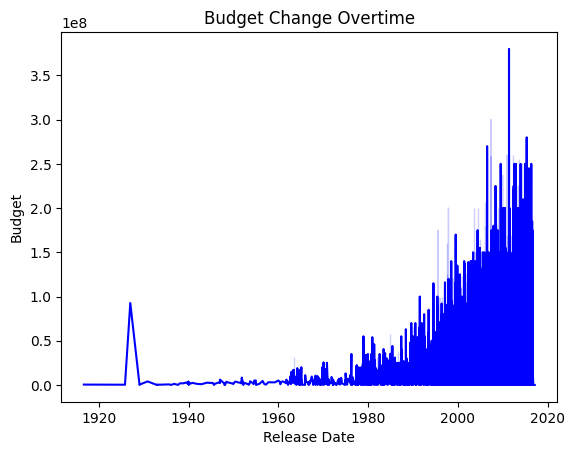

In [21]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

movies['release_date'] = pd.to_datetime(movies['release_date'])

sns.lineplot(data=movies, x='release_date', y='budget', color='blue')

plt.title('Budget Change Overtime')
plt.xlabel('Release Date')
plt.ylabel('Budget')
plt.show()

# 1. Which actor(s) appear the most?




In [22]:
#Create new data frame with just cast column
cast_data = movies[['cast']]
#Explode lists of cast members into individual rows
exploded_cast_data = cast_data.explode('cast')
#Pulls actor names with the highest number of appearances in cast
actor_counts = exploded_cast_data['cast'].value_counts().head(10)
print(actor_counts)


cast
Samuel L. Jackson    67
Robert De Niro       57
Bruce Willis         51
Matt Damon           48
Morgan Freeman       46
Steve Buscemi        43
Liam Neeson          41
Owen Wilson          40
Johnny Depp          40
Alec Baldwin         39
Name: count, dtype: int64


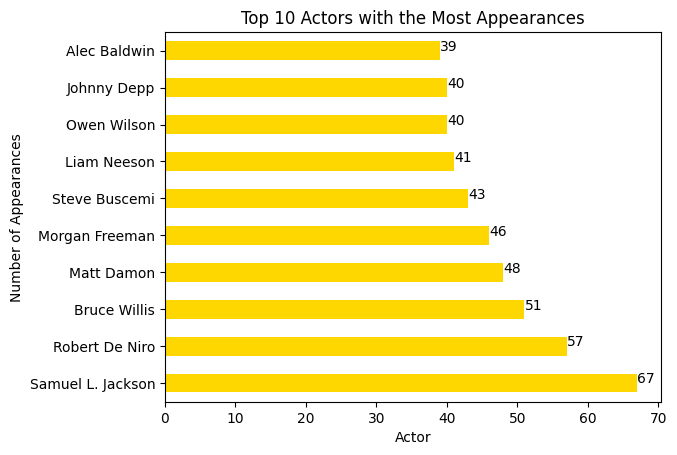

In [23]:
from matplotlib import pyplot as plt

actor_counts.plot(kind='barh',color='gold')

for index, value in enumerate(actor_counts):
    plt.text(value, index, str(value))

plt.xlabel('Actor')
plt.ylabel('Number of Appearances')
plt.title('Top 10 Actors with the Most Appearances')
plt.show()

# 2. Are there specific production companies that consistently produce highly rated Movies



In [24]:
from numpy import average

# Create a data frame with Production Companies and votes Isolated
production_data = movies[['production_companies', 'vote_average']].explode('production_companies')

#Group the Column to be ready for filtering
company_stats = production_data.groupby('production_companies')['vote_average'].agg([
    ('movie_count', 'count'),
    ('average_rating', 'mean')
])

#Filtering companies base on rating and amount of movies that they produced
filtered_companies = company_stats[(company_stats['movie_count'] > 10) & (company_stats['average_rating'] > 6.8)]

print(filtered_companies.head())

                      movie_count  average_rating
production_companies                             
Channel Four Films             13        6.907692
Lucasfilm                      15        7.000000
Malpaso Productions            19        6.842105
Marvel Studios                 13        7.015385
Pathé                          12        6.808333


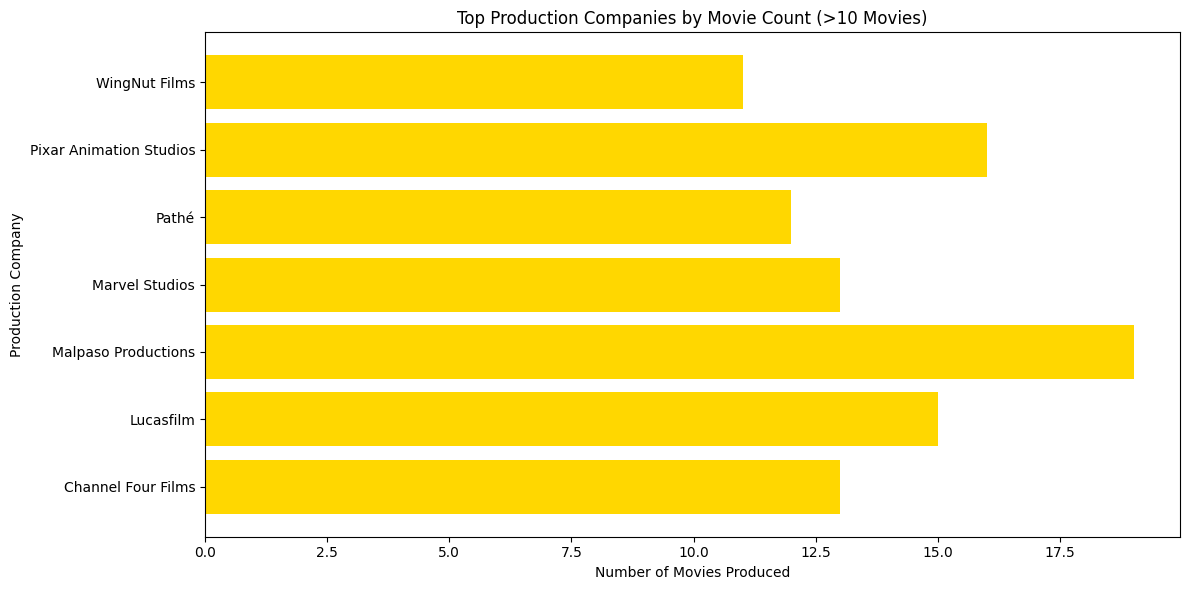

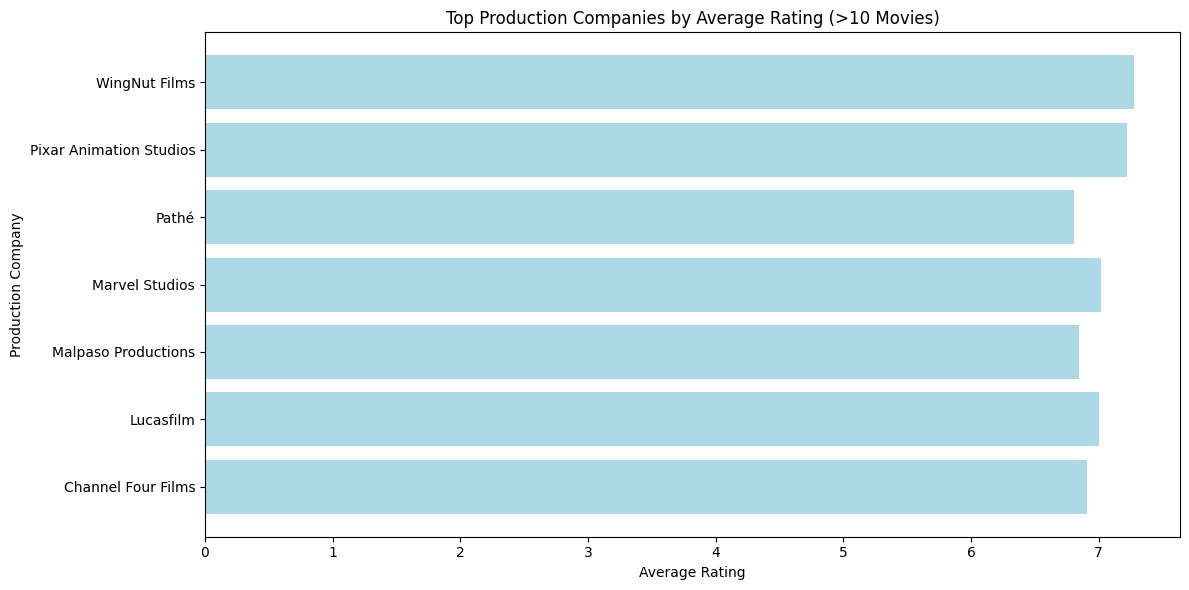

In [25]:
import matplotlib.pyplot as plt
import numpy as np
# Creating visualization for the two set of data
plt.figure(figsize=(12, 6))
plt.barh(filtered_companies.index,
         filtered_companies['movie_count'],
         color='gold')

plt.xlabel('Number of Movies Produced')
plt.ylabel('Production Company')
plt.title('Top Production Companies by Movie Count (>10 Movies)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.barh(filtered_companies.index,
         filtered_companies['average_rating'],
         color='lightblue')

plt.xlabel('Average Rating')
plt.ylabel('Production Company')
plt.title('Top Production Companies by Average Rating (>10 Movies)')
plt.tight_layout()
plt.show()

# 3. Who are the top 5 directors with the most movies?

In [26]:
#Keep only the crew column
directors_data = credits[['crew']].copy()

#Convert crew list into actual python list/dict format
directors_data['crew'] = directors_data['crew'].apply(ast.literal_eval)

#Pulling out the person whose job is director from the crew list
directors_data['director'] = directors_data['crew'].apply(
    lambda crew: next((p['name'] for p in crew if p.get('job') == 'Director'), None)
)

#Remove movies where directors couldn't be found
directors_data = directors_data[directors_data['director']!= None]

#Count how many movies each directors have worked on and show top 5 of them
top_directors = directors_data['director'].value_counts().head(5)

print("Top 5 Directors with the Most Movies:")
print(top_directors)


Top 5 Directors with the Most Movies:
director
Steven Spielberg    27
Woody Allen         21
Clint Eastwood      20
Martin Scorsese     20
Spike Lee           16
Name: count, dtype: int64


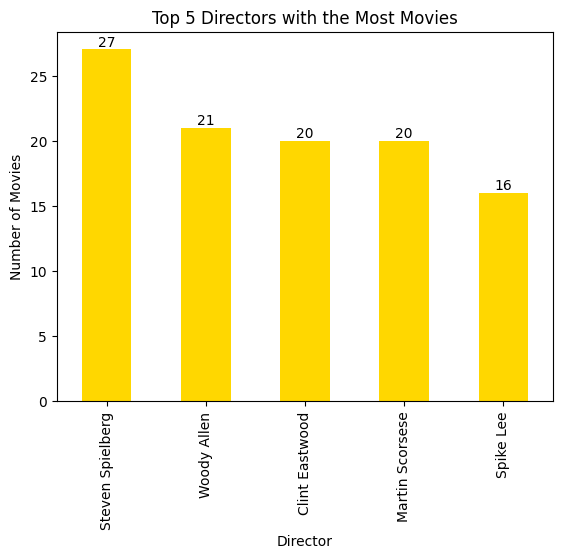

In [27]:
from matplotlib import pyplot as plt

top_directors.plot(kind='bar', color='gold')

for index, value in enumerate(top_directors):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.xlabel('Director')
plt.ylabel('Number of Movies')
plt.title('Top 5 Directors with the Most Movies')
plt.show()

## 4. Are there any actors who frequently collaborate with certain directors? If Yes, List top 10 actor-director collaborations.

In [28]:
# Make a copy of only the cast and crew columns
data = credits[['cast', 'crew']].copy()

# Turn the cast/crew text into actual Python objects
data['cast'] = data['cast'].apply(ast.literal_eval)
data['crew'] = data['crew'].apply(ast.literal_eval)

# Check each movie's crew list and pick out the director's name
data['director'] = data['crew'].apply(
    lambda crew: next((p['name'] for p in crew if p.get('job') == 'Director'), None)
)
# Only the movies where we found a director
data = data[data['director']!= None]

# Expand the cast list so each actor gets their own separate row
data = data.explode('cast')

# Remove rows with missing cast values
data = data[data['cast']!= None]

# Extract actor names
data['actor'] = data['cast'].apply(lambda x: x['name'] if isinstance(x, dict) else None)
data = data[data['actor']!= None]

top_pairs = (data.groupby(['actor', 'director'])
               .size()
               .sort_values(ascending=False)
               .head(10))

print(top_pairs)


actor                      director        
Woody Allen                Woody Allen         13
Danny Trejo                Robert Rodriguez    10
Clint Eastwood             Clint Eastwood      10
Jennifer Schwalbach Smith  Kevin Smith          8
Jason Mewes                Kevin Smith          8
Spike Lee                  Spike Lee            8
Héctor Elizondo            Garry Marshall       8
Giannina Facio             Ridley Scott         8
Tyler Perry                Tyler Perry          8
Cheech Marin               Robert Rodriguez     8
dtype: int64


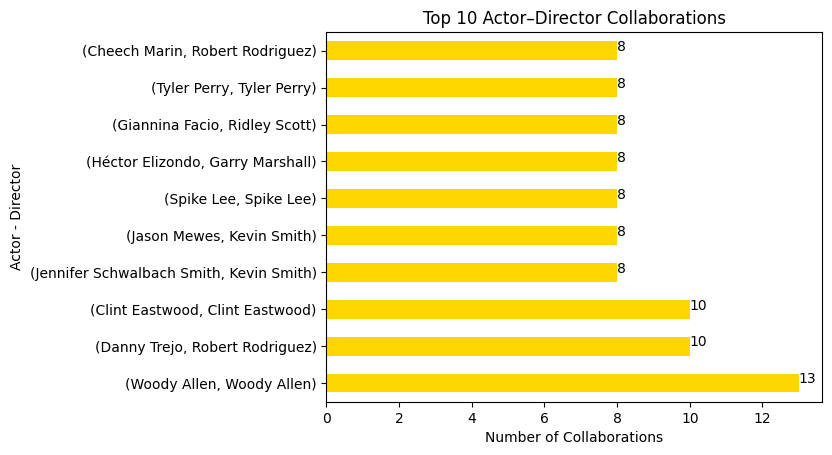

In [29]:
from matplotlib import pyplot as plt

top_pairs.plot(kind='barh', color='gold')

for index, value in enumerate(top_pairs):
    plt.text(value, index, str(value))

plt.xlabel('Number of Collaborations')
plt.ylabel('Actor - Director')
plt.title('Top 10 Actor–Director Collaborations')
plt.show()


## 5.From the start of the data set in 1916 to 2017, which genres were more popular?

In [30]:
# Keep only release dates and genres
genre_data = movies[['release_date', 'genres']].copy()

# Remove missing genres
genre_data = genre_data[genre_data['genres'] != None]

# Convert release date to proper date format
genre_data['release_date'] = pd.to_datetime(genre_data['release_date'], errors='coerce')

# Remove movies with invalid dates
genre_data = genre_data[genre_data['release_date'] != None]

# Extract the year for filtering
genre_data['year'] = genre_data['release_date'].dt.year

# Keep only movies between 1916 and 2017
genre_data = genre_data[(genre_data['year'] >= 1916) & (genre_data['year'] <= 2017)]

# Seperate multiple genres into different rows
genre_data = genre_data.explode('genres')

# Get genre names from the dictionaries
def get_genre_name(x):
    if isinstance(x, dict):
        return x.get('name')
    return x

genre_data['genre_name'] = genre_data['genres'].apply(get_genre_name)

# Remove missing genre names
genre_data = genre_data[genre_data['genre_name'] != None]

# Count movies per genre
top_genres = genre_data['genre_name'].value_counts()

print("Most Popular Genres (1916–2017):")
print(top_genres.head(10))



Most Popular Genres (1916–2017):
genre_name
Drama              2300
Comedy             1723
Thriller           1275
Action             1156
Romance             895
Adventure           792
Crime               697
Science Fiction     538
Horror              520
Family              514
Name: count, dtype: int64


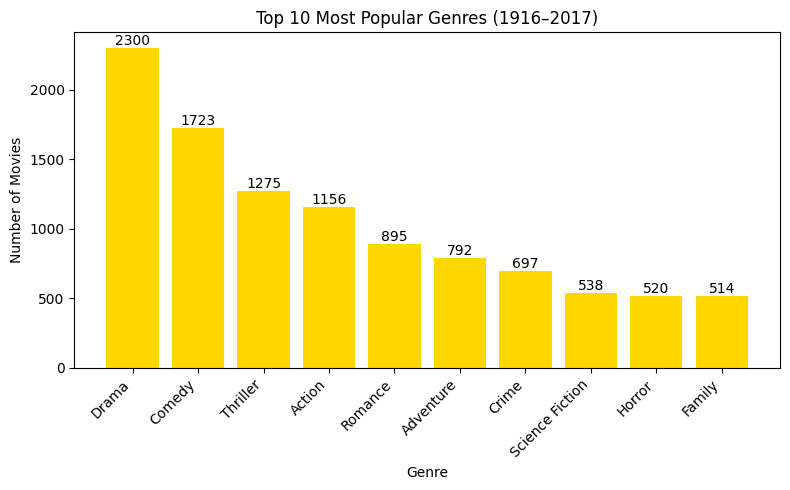

In [31]:
from matplotlib import pyplot as plt

top10_genres = top_genres.head(10)

plt.figure(figsize=(8, 5))

plt.bar(top10_genres.index, top10_genres.values, color='gold')

for i, v in enumerate(top10_genres.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.title('Top 10 Most Popular Genres (1916–2017)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Conclusion

This analysis highlights how movie characteristics such as genre and popularity relate to performance and audience interest. Working with a real-world dataset provided hands-on experience in cleaning data, exploring patterns, and communicating insights through visualizations.

This project reflects both technical growth in Python and the ability to collaborate on data-driven problem solving.
